## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import hypergeom, kendalltau, pearsonr, wilcoxon
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    auc, 
    bootstrap_ci, 
    dtw,
    event_prominence, 
    forgotten_events, 
    format_stats, 
    hypergeom_mc_test, 
    mean_center, 
    prominence_auc, 
    prominence_win_rates, 
    rank_biserial, 
    rdp, 
    rdp_sweep, 
    removal_thresholds, 
    show_source
)

## Functions

In [2]:
show_source(rdp)

In [3]:
show_source(dtw)

In [4]:
show_source(format_stats)

In [5]:
show_source(mean_center)

In [6]:
def hypergeom_z(tp_obs, pool_size, n_good, n_draws):
    """
    Z-score an observed true-positive count against a hypergeometric 
    distribution.
    
    Parameters
    ----------
    tp_obs : int
        Observed true-positive count (successful draws) to z-score.
    pool_size : int
        Number of items in the pool to draw from.
    n_good : int
        Number of "success" items in the pool.
    n_draws : int
        Number of draws to make from the pool, without replacement.
        
    Returns
    -------
    float
        Z-score for for the observed true-positive count.
    """
    mean, var = hypergeom.stats(pool_size, n_good, n_draws, moments='mv')
    return (tp_obs - mean) / np.sqrt(var)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [8]:
# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

In [9]:
EPSILON_STEP = 0.01
EPSILONS = np.arange(0, 2, EPSILON_STEP).round(2)

df = pd.DataFrame(index=range(len(participants) * (len(EPSILONS))), 
                  columns=('participant', 
                           'epsilon', 
                           'n_events_removed', 
                           'n_events_remaining', 
                           'warp_cost'))
df['participant'] = np.repeat([f'P{p.sub_n}' for p in participants], len(EPSILONS))
df['epsilon'] = np.tile(EPSILONS, len(participants))

pbar = tqdm(total=len(df), leave=False)
df_ix = 0
for p_ix in range(len(participants)):
    imm_events = imm_events_centered[p_ix]
    del_events = del_events_centered[p_ix]

    # un-simplified alignment cost (baseline)
    n_events_orig = len(imm_events)
    n_events_remaining = n_events_orig
    n_events_removed = 0
    warp_cost = dtw(imm_events, del_events, metric='cosine', norm_cost=True)[0]
    df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                     n_events_remaining, 
                                                     warp_cost)
    df_ix += 1
    pbar.update()
    
    for epsilon in EPSILONS[1:]:
        imm_simplified = rdp(imm_events, epsilon=epsilon, metric='cosine')
        if len(imm_simplified) != n_events_remaining:
            n_events_remaining = len(imm_simplified)
            n_events_removed = n_events_orig - n_events_remaining
            warp_cost = dtw(imm_simplified, 
                            del_events, 
                            metric='cosine', 
                            norm_cost=True)[0]
        
        df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
                                                         n_events_remaining, 
                                                         warp_cost)
        df_ix += 1
        pbar.update()
        
        if n_events_remaining == 2:
            last_p_row = df.index[df['participant'] == f'P{p_ix + 1}'][-1].item()
            df.loc[
                df_ix:last_p_row, 'n_events_removed':'warp_cost'
            ] = (n_events_removed, n_events_remaining, warp_cost)
            df_ix = last_p_row + 1
            pbar.update(df_ix - pbar.n)
            break
            
df = df.astype({'participant': str, 
                'epsilon': float, 
                'n_events_removed': int, 
                'n_events_remaining': int, 
                'warp_cost': float})
pbar.close()

  0%|          | 0/10600 [00:00<?, ?it/s]

In [10]:
best_alignments = (
    df.loc[
        df.groupby('participant')['warp_cost'].idxmin(), [
            'participant', 
            'epsilon', 
            'n_events_removed', 
            'n_events_remaining', 
            'warp_cost'
        ]
    ]
    .sort_values(
        by='participant', key=lambda pid: pid.str.removeprefix('P').astype(int)
    )
    .reset_index(drop=True)
)

best_alignments['n_events_imm'] = [len(p.events['atlep1']) for p in participants]
best_alignments['n_events_del'] = [len(p.events['delayed']) for p in participants]
best_alignments['n_events_decrease'] = best_alignments['n_events_imm'] - best_alignments['n_events_del']

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease
0,P1,0.42,1,22,0.558993,23,19,4
1,P2,0.00,0,14,0.549072,14,16,-2
2,P3,0.29,1,19,0.468923,20,18,2
3,P4,0.00,0,19,0.397291,19,18,1
4,P5,0.00,0,18,0.466080,18,19,-1


best-fitting tolerance: median=0.00, range=[0.00, 0.82], zero for 27 of 53 participants
events removed at that tolerance: median=0, mean=1.00


<Axes: xlabel='epsilon', ylabel='Count'>

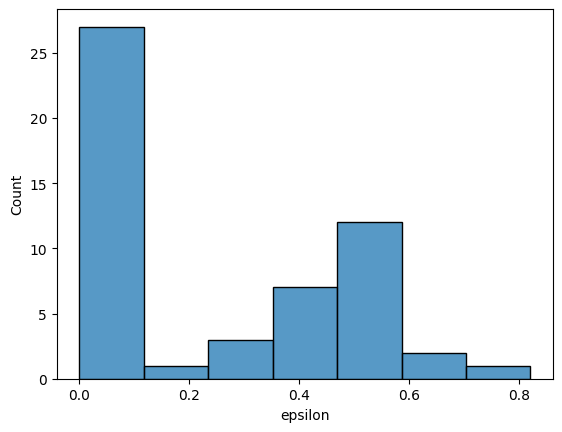

In [11]:
eps = best_alignments['epsilon']
removed = best_alignments['n_events_removed']

# ties in warp cost are resolved in favor of the smallest tolerance, so a zero
# here records the absence of an improvement rather than a positive fit at 0
print(f'best-fitting tolerance: median={eps.median():.2f}, '
      f'range=[{eps.min():.2f}, {eps.max():.2f}], '
      f'zero for {(eps == 0).sum()} of {len(eps)} participants')
print(f'events removed at that tolerance: median={removed.median():.0f}, '
      f'mean={removed.mean():.2f}')

sns.histplot(eps)

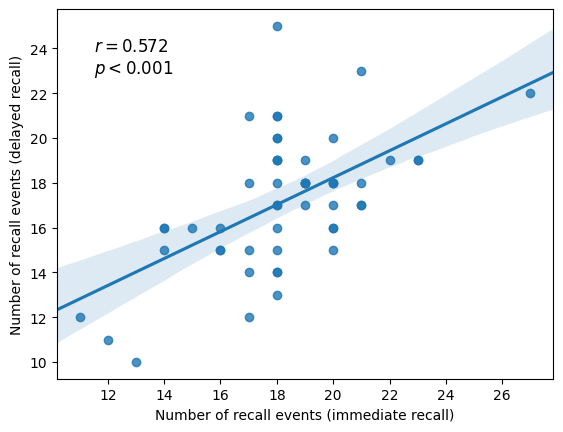

In [12]:
ax = sns.regplot(best_alignments, 
                 x='n_events_imm', 
                 y='n_events_del', 
                 truncate=False)
r, p = pearsonr(best_alignments['n_events_imm'], best_alignments['n_events_del'])
stats_fmt = format_stats(r, p, 'r')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Number of recall events (immediate recall)')
ax.set_ylabel('Number of recall events (delayed recall)')
plt.show()

tau=0.518, p=3.4601e-06, 95% CI [0.356, 0.658], n=53


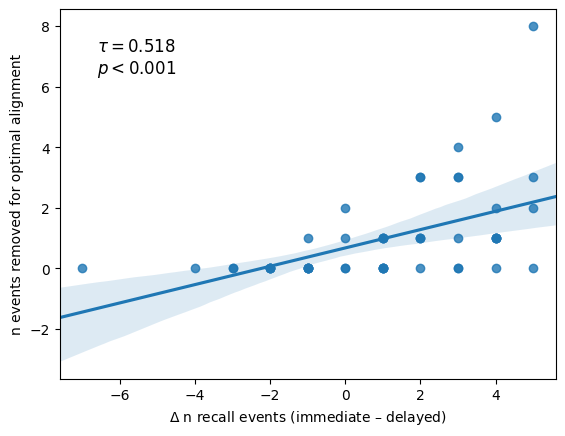

In [13]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease',
                 y='n_events_removed', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['n_events_removed'])
pairs = best_alignments[['n_events_decrease', 'n_events_removed']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('n events removed for optimal alignment')
plt.show()

tau=0.457, p=1.9037e-05, 95% CI [0.289, 0.608], n=53


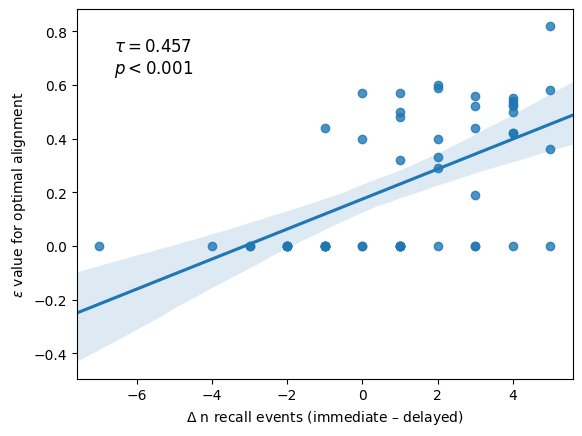

In [14]:
ax = sns.regplot(best_alignments, 
                 x='n_events_decrease', 
                 y='epsilon', 
                 truncate=False)
tau, p = kendalltau(best_alignments['n_events_decrease'], 
                    best_alignments['epsilon'])
pairs = best_alignments[['n_events_decrease', 'epsilon']].to_numpy(dtype=float)
ci_lo, ci_hi = bootstrap_ci(pairs, lambda xy: kendalltau(xy[:, 0], xy[:, 1]).statistic)
print(f'tau={tau:.3f}, p={p:.4e}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], '
      f'n={len(best_alignments)}')
stats_fmt = format_stats(tau, p, '\\tau')
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
ax.set_ylabel('$\\epsilon$ value for optimal alignment')
plt.show()

In [15]:
newcols = [
    'rdp_pred_forgotten', 
    'true_forgotten',
    'true_positives',
    'false_positives',
    'true_negatives',
    'false_negatives'
]
best_alignments[newcols] = np.nan
best_alignments[['rdp_pred_forgotten', 'true_forgotten']] = best_alignments[
    ['rdp_pred_forgotten', 'true_forgotten']
].astype(object)


for ix, row in best_alignments.iterrows():
    p = participants[ix]
    imm_events = imm_events_centered[ix]
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    
    imm_simplified, rec_events_retained = rdp(imm_events, 
                                              epsilon=row['epsilon'], 
                                              metric='cosine', 
                                              return_indices=True)
    ep_events_dropped_rdp = np.delete(imm_event_matches, rec_events_retained)
    pred_forgotten = set(ep_events_dropped_rdp.tolist())
    # events should be deduplicated for analysis, but no duplicates 
    # actually exist in the first place:
    np.testing.assert_array_equal(sorted(ep_events_dropped_rdp), sorted(pred_forgotten))
    best_alignments.at[ix, 'rdp_pred_forgotten'] = pred_forgotten
    
    # exclude first & last immediate recall events since RDP will never
    # remove first or last point
    imm_rec_counts = Counter(imm_event_matches[1:-1].tolist())
    del_rec_counts = Counter(del_event_matches.tolist())
    true_forgotten = set((imm_rec_counts - del_rec_counts).keys())
    best_alignments.at[ix, 'true_forgotten'] = true_forgotten
    
    best_alignments.loc[ix, 'true_positives':'false_negatives'] = (
        # true pos: predicted forgotten & forgotten
        len(pred_forgotten & true_forgotten),
        # false pos: predicted forgotten & not forgotten
        len(pred_forgotten - true_forgotten),
        # true neg: not predicted forgotten & not forgotten
        len(set(imm_rec_counts.keys()) - true_forgotten - pred_forgotten),
        # false neg: forgotten & not predicted forgotten
        len(true_forgotten - pred_forgotten)
    )

best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
] = best_alignments[
    ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
].astype(int)

best_alignments.head()

,participant,epsilon,n_events_removed,n_events_remaining,warp_cost,n_events_imm,n_events_del,n_events_decrease,rdp_pred_forgotten,true_forgotten,true_positives,false_positives,true_negatives,false_negatives
0,P1,0.42,1,22,0.558993,23,19,4,{1},"{10, 4, 13}",0,1,14,3
1,P2,0.00,0,14,0.549072,14,16,-2,{},"{9, 12}",0,0,10,2
2,P3,0.29,1,19,0.468923,20,18,2,{9},"{9, 13}",1,0,16,1
3,P4,0.00,0,19,0.397291,19,18,1,{},"{13, 14}",0,0,14,2
4,P5,0.00,0,18,0.466080,18,19,-1,{},"{13, 4, 12}",0,0,13,3


PearsonRResult(statistic=np.float64(0.517581357686006), pvalue=np.float64(7.221205275103454e-05))

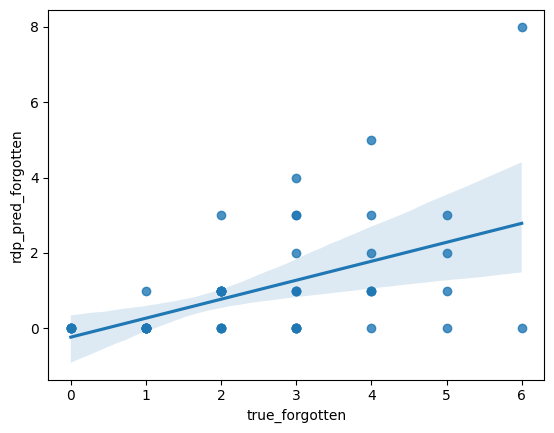

In [16]:
sns.regplot(x=best_alignments['true_forgotten'].apply(len), 
            y=best_alignments['rdp_pred_forgotten'].apply(len))
pearsonr(best_alignments['true_forgotten'].apply(len), best_alignments['rdp_pred_forgotten'].apply(len))

## Analysis 1 (superseded)

Everything from here to the end of Analysis 2 selects a tolerance for each participant by aligning
their simplified immediate recall against their delayed recall, and then asks whether the events
removed at that tolerance are the ones the delayed recall omits. The selection has therefore already
seen the outcome the test evaluates.

The matched null below measures how much that inflates the result, and it is substantial. These
analyses are kept for the record; **the analyses the paper reports are the prominence tests at the
end of this notebook**, which never select a tolerance and never let the delayed recall into the
construction of the predictor.

recall events correctly identified: 22 in total, against 12.9 expected by chance, p=7.9992e-04 (Monte Carlo test over 10,000 hypergeometric draws)
per participant: mean excess=0.172 events, 95% CI [0.064, 0.287], n=53


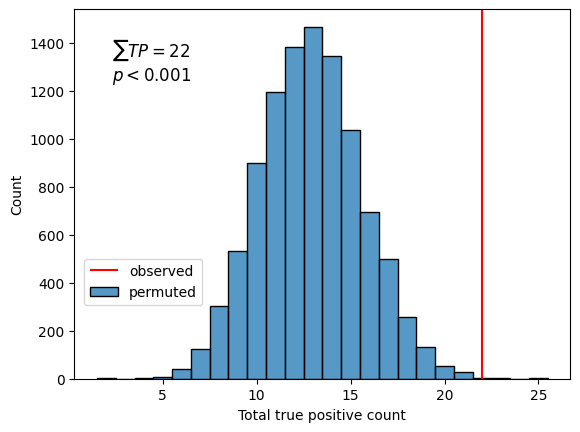

In [17]:
# number of immediate recall events (excluding endpoints)
n_imm_events = best_alignments.loc[:, 'true_positives':'false_negatives'].sum(axis=1).to_numpy()
# number of events actually forgotten
n_true_forgotten = best_alignments[['true_positives', 'false_negatives']].sum(axis=1).to_numpy()
# number of events predicted to be forgotten
n_pred_forgotten = best_alignments[['true_positives', 'false_positives']].sum(axis=1).to_numpy()

obs_tpsum, expected, p, null_tpsums = hypergeom_mc_test(
    n_true_forgotten, 
    n_imm_events - n_true_forgotten, 
    n_pred_forgotten, 
    best_alignments['true_positives']
)

# the excess over the analytic hypergeometric mean, for an effect size with an
# interval on it
expected_each = n_true_forgotten * n_pred_forgotten / n_imm_events
excess = best_alignments['true_positives'].to_numpy() - expected_each
ci_lo, ci_hi = bootstrap_ci(excess, np.mean)

print(f'recall events correctly identified: {obs_tpsum} in total, against '
      f'{expected:.1f} expected by chance, p={p:.4e} '
      f'(Monte Carlo test over {len(null_tpsums):,} hypergeometric draws)')
print(f'per participant: mean excess={excess.mean():.3f} events, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(participants)}')

ax = sns.histplot(null_tpsums, discrete=True, label='permuted')
ax.set_ylim(ax.get_ylim())
ax.vlines(obs_tpsum, *ax.get_ylim(), color='r', label='observed')
ax.legend(loc=(0.02, 0.2))
stats_fmt = format_stats(obs_tpsum, p, '\\sum TP', n_decimals_stat=0)
ax.text(0.075, 0.925, 
        stats_fmt, 
        ha='left', 
        va='top', 
        transform=ax.transAxes, 
        fontsize=12)
ax.set_xlabel('Total true positive count')
plt.show()

### How much of Analysis 1 is the selection?

Which events simplification removes at a given tolerance follows from the shape of a participant's
own path, so the candidate simplifications can be held fixed while the tolerance is instead chosen
against **another participant's** delayed trajectory. Each condition is scored as a ratio of observed
true positives to its own hypergeometric expectation, since choosing the tolerance badly also changes
how many events are removed.

In [18]:
def predicted_forgotten(kept, event_matches, pool):
    """Episode events that simplification dropped, restricted to `pool`."""
    dropped = np.setdiff1d(np.arange(len(event_matches)), kept)
    return set(event_matches[dropped].tolist()) & pool


def hits_and_expectation(target_ix, delayed_events):
    """
    Score one participant's prediction when the tolerance is chosen by aligning
    their own simplifications to `delayed_events`, which need not be their own
    delayed trajectory. Returns the true-positive count and the hypergeometric
    expectation for it.
    """
    candidates, event_matches, pool, forgotten = participant_candidates[target_ix]
    costs = [dtw(simplified, delayed_events, metric='cosine', norm_cost=True)[0]
             for _, simplified, _ in candidates]
    kept = candidates[int(np.argmin(costs))][2]
    predicted = predicted_forgotten(kept, event_matches, pool)
    expected = len(forgotten) * len(predicted) / len(pool)
    return len(predicted & forgotten), expected

In [19]:
# every candidate simplification of each participant's immediate trajectory,
# alongside what they actually forgot. Endpoints are excluded throughout, since
# RDP never removes the first or last point of a trajectory.
participant_candidates = []
for p_ix, p in enumerate(tqdm(participants, leave=False)):
    event_matches = p.event_matches['atlep1']
    pool = set(event_matches[1:-1].tolist())
    forgotten = set((Counter(event_matches[1:-1].tolist())
                     - Counter(p.event_matches['delayed'].tolist())).keys())
    participant_candidates.append(
        (rdp_sweep(imm_events_centered[p_ix], EPSILONS), event_matches, pool, forgotten)
    )

  0%|          | 0/53 [00:00<?, ?it/s]

In [20]:
own_hits = own_expected = 0
for p_ix in range(len(participants)):
    hits, expected = hits_and_expectation(p_ix, del_events_centered[p_ix])
    own_hits += hits
    own_expected += expected
own_ratio = own_hits / own_expected

surrogate_ratios = []
for surrogate_ix in tqdm(range(len(participants)), leave=False):
    hits = expected = 0
    for p_ix in range(len(participants)):
        if p_ix == surrogate_ix:
            continue
        h, e = hits_and_expectation(p_ix, del_events_centered[surrogate_ix])
        hits += h
        expected += e
    surrogate_ratios.append(hits / expected)

surrogate_ratios = np.array(surrogate_ratios)
p = ((surrogate_ratios >= own_ratio).sum() + 1) / (len(surrogate_ratios) + 1)

print(f'own delayed trajectory chooses epsilon:       {own_hits} hits, '
      f'{own_expected:.1f} expected, ratio={own_ratio:.2f}')
print(f'surrogate delayed trajectory chooses epsilon: ratio '
      f'mean={surrogate_ratios.mean():.2f}, s.d.={surrogate_ratios.std(ddof=1):.2f}, '
      f'range=[{surrogate_ratios.min():.2f}, {surrogate_ratios.max():.2f}]')
print(f'own vs surrogate distribution: p={p:.4f}, n={len(participants)} surrogates')

  0%|          | 0/53 [00:00<?, ?it/s]

own delayed trajectory chooses epsilon:       22 hits, 12.9 expected, ratio=1.70
surrogate delayed trajectory chooses epsilon: ratio mean=1.27, s.d.=0.17, range=[0.98, 1.63]
own vs surrogate distribution: p=0.0185, n=53 surrogates


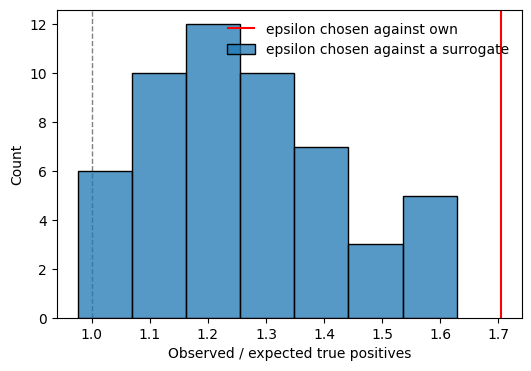

In [21]:
fig, ax = plt.subplots(1, figsize=(6, 4))
sns.histplot(surrogate_ratios, ax=ax, label='epsilon chosen against a surrogate')
ax.set_ylim(ax.get_ylim())
ax.vlines(own_ratio, *ax.get_ylim(), color='r', label='epsilon chosen against own')
ax.axvline(1, c='grey', ls='--', lw=1, zorder=0)
ax.set_xlabel('Observed / expected true positives')
ax.legend(frameon=False)
plt.show()

## Analysis 2 (superseded)

Substitutes other participants' predicted-forgotten sets. This varies the trajectory and the
tolerance selection together, so it does not isolate the selection either.

In [22]:
own_tp_zs = []
other_tp_zs = []
included_participants = []

for ix, row in best_alignments.iterrows():
    p = participants[ix]
    own_pred_forgotten = row['rdp_pred_forgotten']
    true_forgotten = row['true_forgotten']
    
    # only consider participants who actually forgot and were predicted 
    # to forget at least 1 event
    if len(own_pred_forgotten) == 0 or len(true_forgotten) == 0:
        continue
        
    own_tp = row['true_positives']
    pool = set(p.event_matches['atlep1'][1:-1])  # excluding endpoints
    own_tp_z = hypergeom_z(own_tp, 
                           len(pool), 
                           len(true_forgotten), 
                           len(own_pred_forgotten))
    own_tp_zs.append(own_tp_z)
    included_participants.append(p)
    
    _other_tp_zs = []
    for other_ix, other_row in best_alignments.iterrows():
        if other_ix == ix:
            continue
            
        # restrict predicted-forgotten events to those the target 
        # participant recalled (not-recalled events can't be predicted 
        # to be forgotten)
        other_pred_forgotten = other_row['rdp_pred_forgotten'] & pool
        # only consider surrogate participants who were predicted to 
        # forget at least 1 event the target participant recalled (and 
        # so could have forgotten) so own-predictions aren't competing 
        # against artificially poor other-predictions
        if len(other_pred_forgotten) == 0:
            continue
        
        other_tp = len(other_pred_forgotten & true_forgotten)
#         with warnings.catch_warnings():
#             warnings.simplefilter('error')
        other_tp_z = hypergeom_z(other_tp, 
                                 len(pool), 
                                 len(true_forgotten), 
                                 len(other_pred_forgotten))
        _other_tp_zs.append(other_tp_z)
        
    other_tp_zs.append(_other_tp_zs)
    
own_tp_zs = np.array(own_tp_zs)

pct_ranks = np.empty(len(own_tp_zs))
for i, own in enumerate(own_tp_zs):
    other = np.asarray(other_tp_zs[i])
    pct_ranks[i] = ((own > other).sum() + (own == other).sum() * 0.5) / len(other)

T, p = wilcoxon(pct_ranks, 0.5, alternative='greater')
r = rank_biserial(pct_ranks - 0.5)
ci_lo, ci_hi = bootstrap_ci(pct_ranks)

print(f'T={T.item()}, p={p.item():.4e} (one-sided), rank-biserial r={r:.3f}')
print(f'median percentile rank={np.median(pct_ranks):.3f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(included_participants)}')

T=272.0, p=7.1229e-03 (one-sided), rank-biserial r=0.550
median percentile rank=0.714, 95% CI [0.523, 0.840], n=26


## Prominence tests

These are the analyses the paper reports.

The tolerance selection above exists only to answer *how much* to simplify. Sweeping the tolerance
instead of selecting one removes the question entirely: each recall event has a **prominence**, the
tolerance at which simplification first removes it. An event removed early falls close to the line
between its neighbors and is geometrically disposable --- a waypoint --- while an event that survives
to a high tolerance is one whose removal would change the path's shape, a control point.

Prominence is read off a participant's immediate recall trajectory alone. The delayed recall never
enters its construction, and supplies only the labels, so neither test below is circular and neither
involves a threshold.

Two analysis choices are consequential enough to state explicitly, and both are handled in
`analysis_helpers`:

- An episode event described more than once in the immediate recall takes the prominence of its
  **first-removed** occurrence, so an event counts as disposable when any one of its descriptions is.
- Endpoints are excluded **symmetrically**. The pool is the set of episode events described by an
  interior immediate recall event, since simplification never removes a trajectory's endpoints, and
  one delayed occurrence is discounted per endpoint occurrence of the same event so that the two
  sessions are compared on equal footing.

The pair mirrors the DTW analyses: one test against chance, one against other participants.

In [23]:
show_source(event_prominence)

In [24]:
show_source(forgotten_events)

In [25]:
show_source(prominence_auc)

In [26]:
show_source(prominence_win_rates)

In [27]:
participants_prominence = []
for p in tqdm(participants, leave=False):
    imm_events, _ = mean_center(p.events['atlep1'], p.events['delayed'])
    prominence = event_prominence(imm_events, p.event_matches['atlep1'], EPSILONS)
    pool, forgotten = forgotten_events(p.event_matches['atlep1'],
                                       p.event_matches['delayed'])
    participants_prominence.append((prominence, pool, forgotten))

  0%|          | 0/53 [00:00<?, ?it/s]

### Against chance

Does a participant's own prominence ranking separate the events they forgot from the ones they kept?
One-sided, since the hypothesis is directional: disposable events should be the ones that go.

In [28]:
prominence_aucs = np.array([
    a for a in (prominence_auc(prom, pool, forgotten)
                for prom, pool, forgotten in participants_prominence)
    if a is not None
])
T, p = wilcoxon(prominence_aucs - 0.5, alternative='greater')
ci_lo, ci_hi = bootstrap_ci(prominence_aucs, np.mean)

excluded = [(pool, forgotten) for _, pool, forgotten in participants_prominence
            if not forgotten or len(forgotten) == len(pool)]
print(f'participants with at least one forgotten and one retained event: '
      f'{len(prominence_aucs)} of {len(participants)}')
print(f'excluded: {sum(1 for _, f in excluded if not f)} dropped none of the events '
      f'they had described, {sum(1 for p, f in excluded if f and len(f) == len(p))} '
      f'dropped every one')
print(f'AUC: mean={prominence_aucs.mean():.3f}, median={np.median(prominence_aucs):.3f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'vs chance (0.5): T={T.item()}, p={p.item():.4f} (one-sided), '
      f'rank-biserial r={rank_biserial(prominence_aucs - 0.5):.3f}')

participants with at least one forgotten and one retained event: 48 of 53
excluded: 5 dropped none of the events they had described, 0 dropped every one
AUC: mean=0.576, median=0.571, 95% CI [0.522, 0.629]
vs chance (0.5): T=755.5, p=0.0036 (one-sided), rank-biserial r=0.460


### Against other participants

Does a participant's own prominence ranking predict their forgetting better than other participants'
rankings do? Each comparison is made over the episode events **both** described, so a participant's
own ranking gains no advantage from covering more of the episode. A participant is included once at
least five other rankings are comparable to theirs on at least three shared events.

In [29]:
win_rates = prominence_win_rates(participants_prominence)
T, p = wilcoxon(win_rates - 0.5, alternative='greater')
ci_lo, ci_hi = bootstrap_ci(win_rates, np.mean)

print(f'participants included: {len(win_rates)} of {len(participants)}')
print(f"win rate against other participants' rankings: mean={win_rates.mean():.3f}, "
      f'median={np.median(win_rates):.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'vs chance (0.5): T={T.item()}, p={p.item():.4f} (one-sided), '
      f'rank-biserial r={rank_biserial(win_rates - 0.5):.3f}')

participants included: 48 of 53
win rate against other participants' rankings: mean=0.606, median=0.657, 95% CI [0.535, 0.676]
vs chance (0.5): T=848.0, p=0.0038 (one-sided), rank-biserial r=0.442


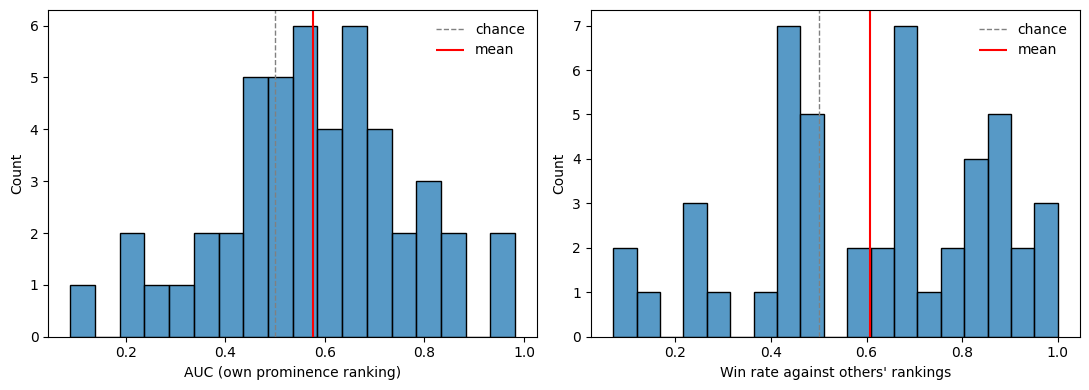

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, values, label in ((axes[0], prominence_aucs, 'AUC (own prominence ranking)'),
                          (axes[1], win_rates, 'Win rate against others\' rankings')):
    sns.histplot(values, binwidth=0.05, ax=ax)
    ax.set_ylim(ax.get_ylim())
    ax.vlines(0.5, *ax.get_ylim(), color='grey', ls='--', lw=1, label='chance')
    ax.vlines(values.mean(), *ax.get_ylim(), color='r', label='mean')
    ax.set_xlabel(label)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### How much do the two conventions matter?

Both choices described above are judgement calls, and neither was fixed before the analysis was run,
so it is worth knowing what each contributes. `event_prominence` and `forgotten_events` take them as
arguments precisely so this can be measured rather than asserted.

- **dedup**: an episode event described more than once scored by its `'first'`-removed occurrence, or
  by the `'mean'` across its occurrences.
- **endpoint offset**: whether one delayed occurrence is discounted per endpoint occurrence of the
  same episode event, keeping the two sessions on equal footing.

In [31]:
sensitivity = []
for dedup in ('first', 'mean'):
    for endpoint_offset in (True, False):
        rankings = []
        for p in participants:
            imm_events, _ = mean_center(p.events['atlep1'], p.events['delayed'])
            rankings.append((
                event_prominence(imm_events, p.event_matches['atlep1'], EPSILONS, dedup=dedup),
                *forgotten_events(p.event_matches['atlep1'], p.event_matches['delayed'],
                                  endpoint_offset=endpoint_offset)
            ))
        aucs = np.array([a for a in (prominence_auc(prom, pool, forgotten)
                                     for prom, pool, forgotten in rankings) if a is not None])
        wins = prominence_win_rates(rankings)
        sensitivity.append({
            'dedup': dedup,
            'endpoint offset': endpoint_offset,
            'n': len(aucs),
            'AUC': aucs.mean(),
            'p (chance)': wilcoxon(aucs - 0.5, alternative='greater').pvalue,
            'win rate': wins.mean(),
            'p (others)': wilcoxon(wins - 0.5, alternative='greater').pvalue
        })

sensitivity = pd.DataFrame(sensitivity)
print(sensitivity.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

dedup  endpoint offset  n    AUC  p (chance)  win rate  p (others)
first             True 48 0.5757      0.0036    0.6064      0.0038
first            False 47 0.5694      0.0133    0.5896      0.0152
 mean             True 48 0.5551      0.0230    0.5758      0.0195
 mean            False 47 0.5446      0.0789    0.5562      0.0835


The reported configuration is the first row. Dropping either convention on its own leaves both
tests reliable; dropping both together leaves them at the edge of conventional significance. This is
the sensitivity the Results section quotes.